
importing necessary library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

importing dataset

In [2]:
data = pd.read_csv("usa_rain_prediction_dataset_2024_2025.csv")
data

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0
...,...,...,...,...,...,...,...,...,...
73095,2025-12-27,Washington D.C.,40.614393,65.099438,28.778327,0.000000,54.168514,977.083747,0
73096,2025-12-28,Washington D.C.,52.641643,30.610525,12.282890,0.871000,22.068055,980.591675,0
73097,2025-12-29,Washington D.C.,56.492591,96.740232,2.894762,1.191956,52.336048,1016.469174,1
73098,2025-12-30,Washington D.C.,65.748956,63.900004,24.632400,0.483421,76.785280,1032.396146,1


In [3]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [4]:
data.shape

(73100, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           73100 non-null  object 
 1   Location       73100 non-null  object 
 2   Temperature    73100 non-null  float64
 3   Humidity       73100 non-null  float64
 4   Wind Speed     73100 non-null  float64
 5   Precipitation  73100 non-null  float64
 6   Cloud Cover    73100 non-null  float64
 7   Pressure       73100 non-null  float64
 8   Rain Tomorrow  73100 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 5.0+ MB


In [6]:
data.columns

Index(['Date', 'Location', 'Temperature', 'Humidity', 'Wind Speed',
       'Precipitation', 'Cloud Cover', 'Pressure', 'Rain Tomorrow'],
      dtype='object')

In [7]:
data.head()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [8]:
data.tail()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
73095,2025-12-27,Washington D.C.,40.614393,65.099438,28.778327,0.000000,54.168514,977.083747,0
73096,2025-12-28,Washington D.C.,52.641643,30.610525,12.282890,0.871000,22.068055,980.591675,0
73097,2025-12-29,Washington D.C.,56.492591,96.740232,2.894762,1.191956,52.336048,1016.469174,1
73098,2025-12-30,Washington D.C.,65.748956,63.900004,24.632400,0.483421,76.785280,1032.396146,1
73099,2025-12-31,Washington D.C.,54.648609,80.812021,22.722505,0.151903,19.674960,974.835534,0


In [9]:
data.describe()

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,65.182270,59.875041,15.017946,0.390635,54.942807,1005.176013,0.220410
std,20.205793,23.066115,8.668729,0.474833,25.982487,20.203889,0.414526
min,30.000766,20.000272,0.000712,0.000000,10.000856,970.000919,0.000000
25%,47.678968,39.800732,7.485182,0.000000,32.318668,987.697646,0.000000
50%,65.294949,59.887840,15.102495,0.196909,55.011121,1005.284188,0.000000
75%,82.636570,79.835990,22.551794,0.673177,77.412469,1022.727410,0.000000
max,99.997393,99.999025,29.999017,3.078090,99.998957,1039.999765,1.000000


removing unnecessary feature



In [10]:
data = data.drop(columns=['Date', "Location"])
data

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0
...,...,...,...,...,...,...,...
73095,40.614393,65.099438,28.778327,0.000000,54.168514,977.083747,0
73096,52.641643,30.610525,12.282890,0.871000,22.068055,980.591675,0
73097,56.492591,96.740232,2.894762,1.191956,52.336048,1016.469174,1
73098,65.748956,63.900004,24.632400,0.483421,76.785280,1032.396146,1


In [11]:
data.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover',
       'Pressure', 'Rain Tomorrow'],
      dtype='object')

In [12]:
data.fillna(data.mean(), inplace=True)

checking null value

In [13]:
data.isnull().sum()

Temperature      0
Humidity         0
Wind Speed       0
Precipitation    0
Cloud Cover      0
Pressure         0
Rain Tomorrow    0
dtype: int64

In [14]:

data = data.dropna()
data = data.apply(pd.to_numeric, errors='coerce')


In [15]:
data['Rain Tomorrow'].unique()

array([0, 1])

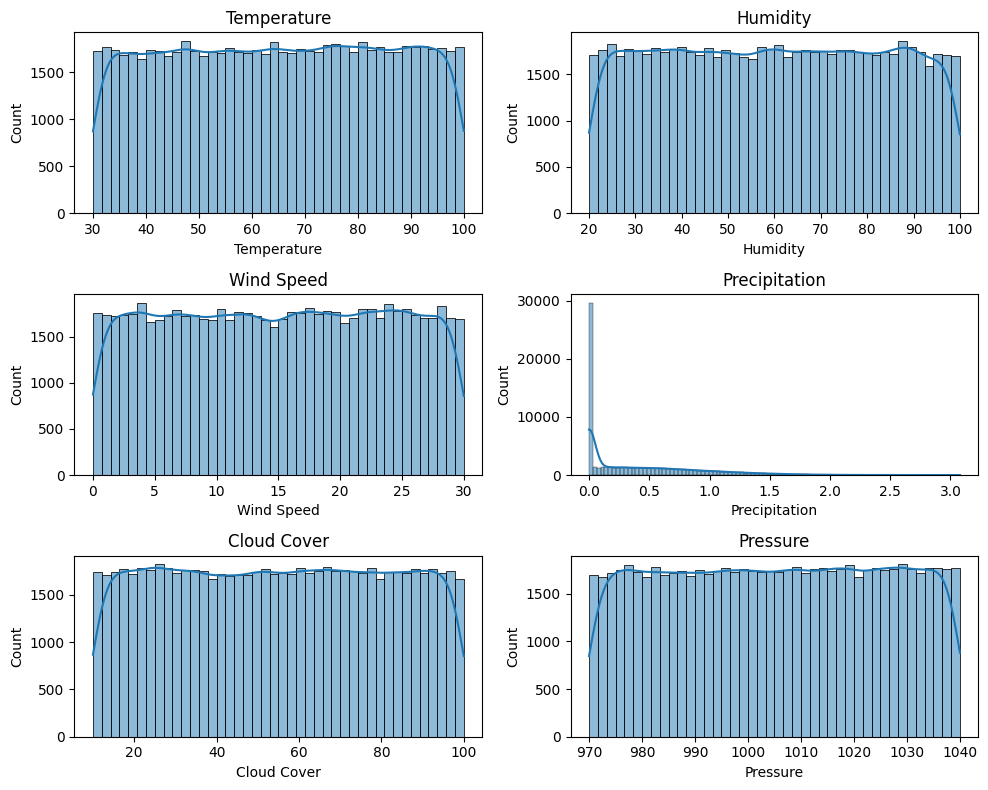

In [16]:
plt.figure(figsize=(10,8))
for i, column in enumerate(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover','Pressure'],1):
    plt.subplot(3, 2, i)
    sns.histplot(data[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

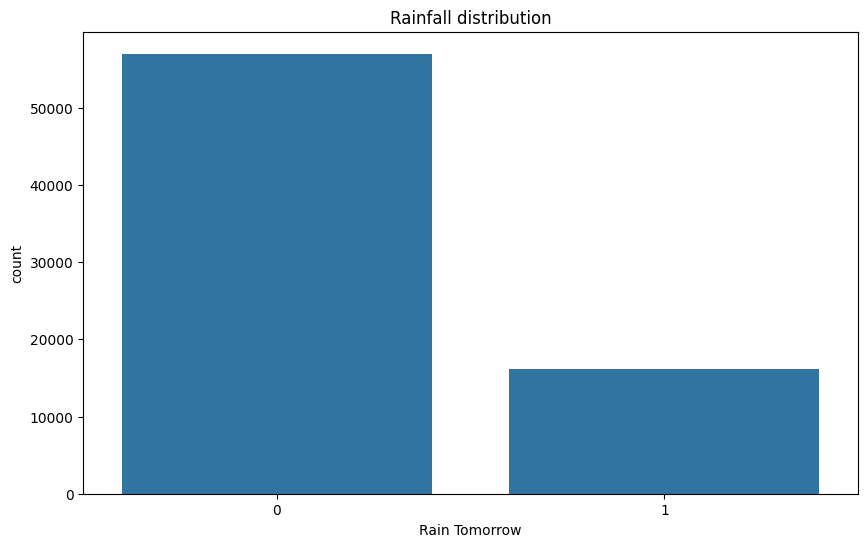

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x = "Rain Tomorrow", data = data)
plt.title('Rainfall distribution')
plt.show()

finding coorelation

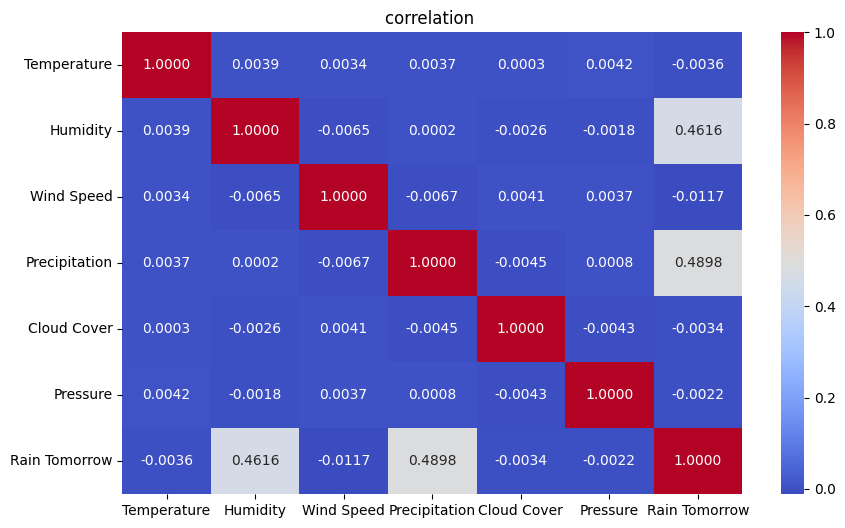

In [18]:
# correlation
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap = "coolwarm", fmt = ".4f")
plt.title("correlation ")
plt.show()

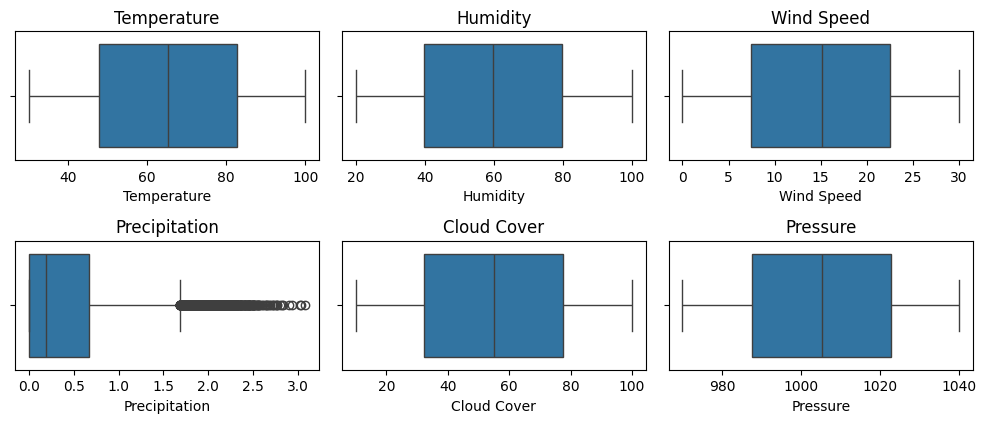

In [19]:
plt.figure(figsize=(10,6))
for i, column in enumerate(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover','Pressure'],1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

In [20]:
Q1 = data['Precipitation'].quantile(0.25)
Q3 = data['Precipitation'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers = data[(data['Precipitation'] >= lower_bound) & (data['Precipitation'] <= upper_bound)]


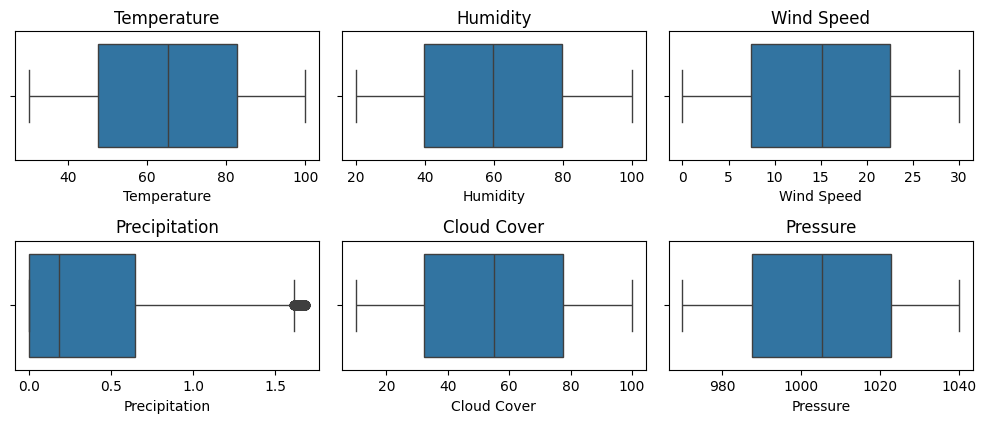

In [21]:
plt.figure(figsize=(10,6))
for i, column in enumerate(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover', 'Pressure'], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data_no_outliers[column])
    plt.title(column)
plt.tight_layout()
plt.show()

In [22]:
data['Rain Tomorrow'].value_counts()

Rain Tomorrow
0    56988
1    16112
Name: count, dtype: int64

In [23]:
data_majority = data[data['Rain Tomorrow'] == 0]
data_minority = data[data['Rain Tomorrow'] == 1]

In [24]:
data_majority.shape

(56988, 7)

In [25]:
data_minority.shape


(16112, 7)

Here we can see the huge data gap between them. We use random forest classifier. thats why we need to label it or model will be trained wrong way

In [26]:
data_majority_downsampled = resample(data_majority, replace=False, n_samples=len(data_minority), random_state=42)

In [27]:
data_majority_downsampled.shape


(16112, 7)

well... now we have both equal shape data. 

In [28]:
data_minority.shape

(16112, 7)

In [29]:
data_downsampled = pd.concat([data_majority_downsampled,data_minority])

In [30]:
data_downsampled.shape

(32224, 7)

In [31]:
data_downsampled

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
21935,49.726217,81.318814,22.506603,0.000000,92.311549,1002.897052,0
57328,40.175202,31.387391,23.275314,1.641597,76.461919,1022.595760,0
35140,32.136080,55.540792,10.062831,0.523359,70.170411,1013.945702,0
15776,46.110795,87.291368,26.372381,0.000000,47.648849,1024.695089,0
39289,60.060121,48.536574,22.526429,0.000000,15.768850,1007.397149,0
...,...,...,...,...,...,...,...
73084,55.228214,71.684053,5.220591,0.816960,25.422520,1033.954127,1
73089,46.313829,72.077764,8.011233,0.420991,27.831766,1001.895164,1
73091,46.404509,70.579704,3.060659,2.147562,64.891195,1011.290646,1
73097,56.492591,96.740232,2.894762,1.191956,52.336048,1016.469174,1


In [32]:
data_downsampled['Rain Tomorrow'].value_counts()

Rain Tomorrow
0    16112
1    16112
Name: count, dtype: int64

Split features and target

In [33]:
x  = data_downsampled.drop(columns= "Rain Tomorrow")
y = data_downsampled['Rain Tomorrow']

In [34]:
x

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure
21935,49.726217,81.318814,22.506603,0.000000,92.311549,1002.897052
57328,40.175202,31.387391,23.275314,1.641597,76.461919,1022.595760
35140,32.136080,55.540792,10.062831,0.523359,70.170411,1013.945702
15776,46.110795,87.291368,26.372381,0.000000,47.648849,1024.695089
39289,60.060121,48.536574,22.526429,0.000000,15.768850,1007.397149
...,...,...,...,...,...,...
73084,55.228214,71.684053,5.220591,0.816960,25.422520,1033.954127
73089,46.313829,72.077764,8.011233,0.420991,27.831766,1001.895164
73091,46.404509,70.579704,3.060659,2.147562,64.891195,1011.290646
73097,56.492591,96.740232,2.894762,1.191956,52.336048,1016.469174


In [35]:
y

21935    0
57328    0
35140    0
15776    0
39289    0
        ..
73084    1
73089    1
73091    1
73097    1
73098    1
Name: Rain Tomorrow, Length: 32224, dtype: int64

spliting the train and test data

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

okay. now code for model

In [37]:
RF_model = RandomForestClassifier(random_state=42)
pram_grid_RF = {
    "n_estimators": [50, 100, 200],
    "max_features": ["sqrt", "log2"],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [38]:
grid_search_RF = GridSearchCV(estimator=RF_model, param_grid=pram_grid_RF, cv=5, n_jobs=-1, verbose=2)
grid_search_RF.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\ARAFAT\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [39]:
best_RF_model = grid_search_RF.best_estimator_
print(f'best parameter for random forest{grid_search_RF.best_params_}')

best parameter for random forest{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [40]:
cv_score = cross_val_score(best_RF_model, x_train, y_train, cv=5)
print(f'cross validation score for random forest {cv_score}')
print(f'mean cross validation score for random forest {np.mean(cv_score)}')

cross validation score for random forest [1.         0.99980605 1.         1.         1.        ]
mean cross validation score for random forest 0.9999612102404966


In [41]:
print(f"Train set accuracy:\n {accuracy_score(y_train, best_RF_model.predict(x_train))}")

Train set accuracy:
 1.0


In [42]:
y_pred = best_RF_model.predict(x_test)
print(f'test set accuracy:\n {accuracy_score(y_test, y_pred)}')
print(f'classification report:\n {classification_report(y_test, y_pred)}')
print(f'confusion matrix: \n {confusion_matrix(y_test, y_pred)}')

test set accuracy:
 1.0
classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3252
           1       1.00      1.00      1.00      3193

    accuracy                           1.00      6445
   macro avg       1.00      1.00      1.00      6445
weighted avg       1.00      1.00      1.00      6445

confusion matrix: 
 [[3252    0]
 [   0 3193]]


In [43]:
input = (70, 90, 15, 0.1, 14.2, 699)
input_data = pd.DataFrame([input], columns=['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover', 'Pressure'])
prediction = best_RF_model.predict(input_data)
if prediction[0] == 0:
    print("No rain tomorrow")
else:
    print("Rain tomorrow")

No rain tomorrow


In [44]:
import pickle

In [45]:
# save model and feature in pickle file
model_data = {
    "model": best_RF_model, 
    "feature_names": x.columns.tolist()
}
with open("University_Ml_Project.pkl", "wb") as file:
    pickle.dump(model_data, file)

In [46]:
with open("University_ML_project.pkl", "rb") as file:
    data = pickle.load(file)

print(type(data))
print(data)

<class 'dict'>
{'model': RandomForestClassifier(n_estimators=50, random_state=42), 'feature_names': ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover', 'Pressure']}
